In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices, 
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from run import run,initialize


In [2]:
CONF = {
        "n_units": 2,
        "n_families": 2,
        "latent_dim": 5,
        "k_sub": 5,
        "batch_size": 1024,
        "epochs": 600,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[0,0,0,0,0],[1,1,1,1,1]],dtype=torch.long),
        "init_means":[3.,2.] # size must be n_families
    }

In [8]:
env,physics,loss_fn,optimize = initialize(CONF)

Fitting UMAP... (This may take a few seconds)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


(<Figure size 800x400 with 5 Axes>,
 <Axes: title={'center': 'UMAP Projection of 5D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

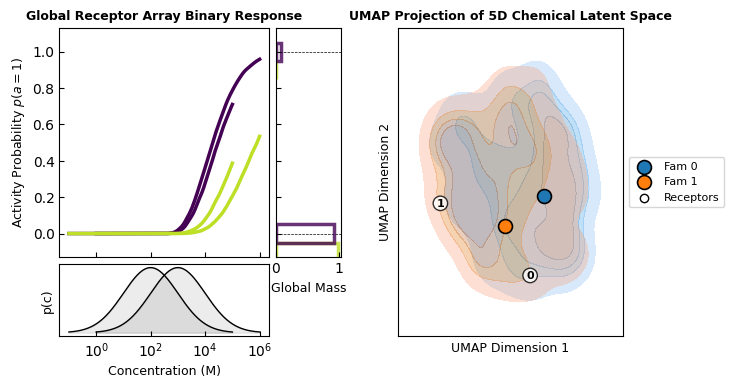

In [9]:
fig,axs = plt.subplots(ncols=2,figsize=(8,4))
plot_summary(env,physics,CONF["receptor_indices"],axes=axs[0])
plot_latent_umap(env,CONF["receptor_indices"],ax=axs[1])

In [10]:
stats = run(CONF,env,physics,loss_fn,optimize)

Training for 600 epochs...
Total Correlation: 0.0402
Total Correlation: 0.0749
Total Correlation: 0.1451
Total Correlation: 0.1521
Total Correlation: 0.1345
Total Correlation: 0.1024
Total Correlation: 0.1364
Total Correlation: 0.1271
Total Correlation: 0.1090
Total Correlation: 0.1267
Total Correlation: 0.1139
Total Correlation: 0.1524
Total Correlation: 0.1239
Total Correlation: 0.0872
Total Correlation: 0.0681
Total Correlation: 0.0468
Total Correlation: 0.0755
Total Correlation: 0.0751
Total Correlation: 0.0519
Total Correlation: 0.0462
Total Correlation: 0.0495
Total Correlation: 0.0432
Total Correlation: 0.0356
Total Correlation: 0.0399
Total Correlation: 0.0329
Total Correlation: 0.0173
Total Correlation: 0.0299
Total Correlation: 0.0146
Total Correlation: 0.0087
Total Correlation: 0.0173
Total Correlation: 0.0144
Total Correlation: 0.0190
Total Correlation: 0.0052
Total Correlation: 0.0087
Total Correlation: 0.0122
Total Correlation: 0.0200
Total Correlation: 0.0077
Total Corre

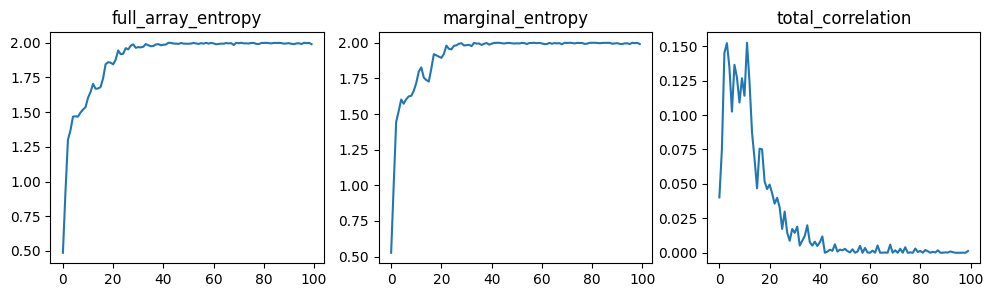

In [11]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
for i,key in enumerate(stats.keys()):
    ax[i].plot(stats[key])
    ax[i].set_title(key)

Fitting UMAP... (This may take a few seconds)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


(<Figure size 800x400 with 5 Axes>,
 <Axes: title={'center': 'UMAP Projection of 5D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

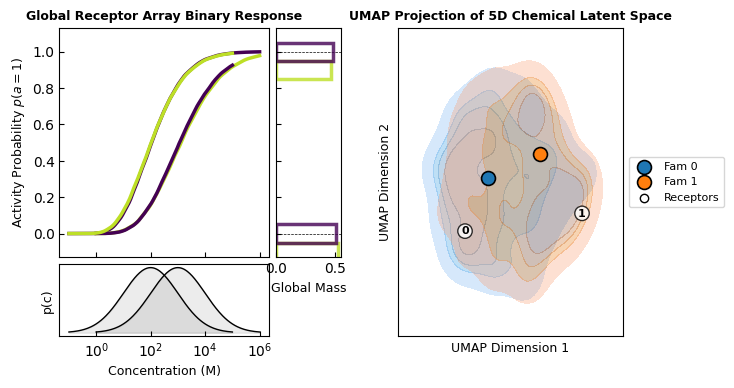

In [12]:
fig,axs = plt.subplots(ncols=2,figsize=(8,4))
plot_summary(env,physics,CONF["receptor_indices"],axes=axs[0])
plot_latent_umap(env,CONF["receptor_indices"],ax=axs[1])

In [13]:
env.concentration_model.mu

tensor([3., 2.], device='cuda:0')